# ECBME 4070/6070 Homework 4

Completed by Alexander Speer [aes2376] and Ciro Randazzo [cr3510]

*GenAI usage statement: Claude Code was used to check, but not to generate, code.*


**(1) Characterizing the Active Receptor Model (cont’d), An Example: Re-
sponse to Step, Ramp and Parabola Stimuli, Lecture #8, slide #49.**


**(2) I/O Characterization of the OTP Model (cont’d), An Example: Re-
sponse to Step, Ramp and Parabola Stimuli, Lecture #8, slide 50**


**(3) I/O Characterization of the Connors-Stevens Neuron (CS Model), Lec-
ture #8, slide #56, 2D plot on the left.**

(Part 1)


In [ ]:
import numpy as np

# this cell is going to build the otp cell and the next cell in part 2 is
# going to run it

# this is based off of the materials in lecture 8 (code skeleton too)


def clip01(x):
    # values have to be clipped
    return np.minimum(np.maximum(x, 0.0), 1.0)


def generate_stimulus(t_range, R, O, N, stimulus):
    """
    Generate constant / step / ramp / parabola stimuli as a 4D tensor
    of shape [time, R, O, N].

    If we look at Lecture #8 on page 48 we can see that:
      step:      u_s(t) = c,              0.5 <= t <= 2.5, else 0
      ramp:      u_r(t) = c*(t-0.5)/1.8, 0.5 <= t < 2.3
                           c*(1-5*(t-2.3)), 2.3 <= t < 2.5
                           0 otherwise
      we have the parabola here:  u_p(t) = c*((t-0.5)/1.9)^2, 0.5 <= t < 2.4
                           c*(1-10*(t-2.4))^2, 2.4 <= t < 2.5
                           0 otherwise
    where we have a c value that ranges from 1 to the 101 with a time step size 5.
    """
    t_steps = len(t_range)
    u = np.zeros((t_steps, R, O, N), dtype=float)

    # this is going to be our 21 amplitudes: sample vaules @ 1, 6, 11, ..., 101
    c_vals = np.arange(1.0, 102.0, 5.0)

    for i, c in enumerate(c_vals):
        if stimulus == "constant":
            # this is going to be important for all the steady-state experiments later.
            # have to make sure to keep constant from the t=0 onward.
            wave = np.full_like(t_range, c, dtype=float)

        elif stimulus == "step":
            wave = np.where((t_range >= 0.5) & (t_range <= 2.5), c, 0.0)

        elif stimulus == "ramp":
            wave = np.zeros_like(t_range, dtype=float)

            mask1 = (t_range >= 0.5) & (t_range < 2.3)
            wave[mask1] = c * ((t_range[mask1] - 0.5) / 1.8)

            mask2 = (t_range >= 2.3) & (t_range < 2.5)
            wave[mask2] = c * (1.0 - 5.0 * (t_range[mask2] - 2.3))

            wave = np.maximum(wave, 0.0)

        elif stimulus == "parabola":  # just roll them all out
            wave = np.zeros_like(t_range, dtype=float)

            mask1 = (t_range >= 0.5) & (t_range < 2.4)
            wave[mask1] = c * ((t_range[mask1] - 0.5) / 1.9) ** 2

            mask2 = (t_range >= 2.4) & (t_range < 2.5)
            wave[mask2] = c * (1.0 - 10.0 * (t_range[mask2] - 2.4)) ** 2

            wave = np.maximum(wave, 0.0)

        else:
            raise ValueError(f"you messed up, stimulus : {stimulus}")

        u[:, :, :, i] = wave[:, None, None]

    return u


def filter_u_h(t_range, u, alpha_1, beta_1, gradient=False):
    """
    this is the block for the Peri-receptor process filter.

    Once again, referencing the Lecture #8 materials on
    page 39, we can see that were given h(t) as the impulse response of:
        d^2h/dt^2 + 2*alpha_1*beta_1 * dh/dt + alpha_1^2 * h = alpha_1^2 * delta(t)

    and then we can implement the equivalent second-order low-pass dynamics that
    is also included:
        x1' = x2
        x2' = alpha_1^2 * input - 2*alpha_1*beta_1 * x2 - alpha_1^2 * x1

    then we can work our logic out to be something like this;
    If the gradient=True, then the filter input is du/dt.
    then lets have our function returns the filtered signal x1.
    """
    t_steps = len(t_range)
    dt = t_range[1] - t_range[0]
    inp = np.array(u, dtype=float)
    if gradient:
        du = np.zeros_like(inp)
        du[1:] = (inp[1:] - inp[:-1]) / dt
        inp = du
    x1 = np.zeros_like(inp, dtype=float)
    x2 = np.zeros_like(inp, dtype=float)

    for k in range(t_steps - 1):
        dx1 = x2[k]
        dx2 = (
            (alpha_1**2) * inp[k]
            - 2.0 * alpha_1 * beta_1 * x2[k]
            - (alpha_1**2) * x1[k]
        )
        x1[k + 1] = x1[k] + dt * dx1
        x2[k + 1] = x2[k] + dt * dx2

    return x1


def sim_otp(t_range, v, b, d, alpha_2, beta_2, kappa, alpha_3, beta_3, c, p, I_max):
    """
     the OTP state equations also from Lecture #8 page 46:
        dx1/dt = b*v*(1-x1) - d*x1
        dx2/dt = alpha_2*x1*(1-x2) - beta_2*x2 - kappa*x2^(2/3)*x3^(2/3)
        dx3/dt = alpha_3*x2 - beta_3*x3
        I = (x2^p / (x2^p + c^p)) * I_max

    we have the handout that says:
      - v cannot be negative
      - keep x1, x2 in [0, 1]
      kjeep in mind
    """
    t_steps = len(t_range)
    dt = t_range[1] - t_range[0]
    v = np.maximum(v, 0.0)
    x1 = np.zeros_like(v, dtype=float)
    x2 = np.zeros_like(v, dtype=float)
    x3 = np.zeros_like(v, dtype=float)
    I = np.zeros_like(v, dtype=float)

    for k in range(t_steps - 1):
        dx1 = b[k] * v[k] * (1.0 - x1[k]) - d[k] * x1[k]

        #  noticed that there were these franctional  powers thatappear in
        # appear  in Lecture #8 pages 43 and 46
        x2_term = np.maximum(x2[k], 0.0) ** (2.0 / 3.0)
        x3_term = np.maximum(x3[k], 0.0) ** (2.0 / 3.0)

        dx2 = (
            alpha_2 * x1[k] * (1.0 - x2[k]) - beta_2 * x2[k] - kappa * x2_term * x3_term
        )
        dx3 = alpha_3 * x2[k] - beta_3 * x3[k]

        x1[k + 1] = clip01(x1[k] + dt * dx1)
        x2[k + 1] = clip01(x2[k] + dt * dx2)
        x3[k + 1] = np.maximum(x3[k] + dt * dx3, 0.0)

    x2_pow = np.maximum(x2, 0.0) ** p
    I = (x2_pow / (x2_pow + (c**p))) * I_max

    return x1, x2, x3, I


class OTPModel:
    """
    our model is going to be using the Acetone-Or59b fitted parameters from Lecture #8 page 47.
    """

    def __init__(
        self,
        alpha_1=4.500e1,
        beta_1=8.000e-1,
        gamma=2.105e-1,
        alpha_2=1.461e2,
        beta_2=1.172e2,
        alpha_3=2.539e0,
        beta_3=9.096e-1,
        kappa=8.841e3,
        c=6.546e-2,
        p=1.0,
        I_max=6.213e1,
    ):
        """
        # original params

        alpha_1=1.57e1,
        beta_1=8.00e-1,
        gamma=1.75e-1,
        alpha_2=8.877e1,
        beta_2=9.789e1,
        alpha_3=2.100e0,
        beta_3=1.2e0,
        kappa=7.089e3,
        c=7.534e-2,
        p=1.0,
        I_max=7.774e1,
        """

        self.alpha_1 = alpha_1
        self.beta_1 = beta_1
        self.gamma = gamma
        self.alpha_2 = alpha_2
        self.beta_2 = beta_2
        self.alpha_3 = alpha_3
        self.beta_3 = beta_3
        self.kappa = kappa
        self.c = c
        self.p = p
        self.I_max = I_max

    def sim(self, t_range, b, d, u):  # Full OTP simulation
        u_h = filter_u_h(t_range, u, self.alpha_1, self.beta_1, gradient=False)
        u_h_grad = filter_u_h(t_range, u, self.alpha_1, self.beta_1, gradient=True)
        v = np.maximum(0.0, u_h + self.gamma * u_h_grad)

        b_arr = np.zeros_like(v) + b
        d_arr = np.zeros_like(v) + d
        x1, x2, x3, I = sim_otp(
            t_range,
            v,
            b_arr,
            d_arr,
            self.alpha_2,
            self.beta_2,
            self.kappa,
            self.alpha_3,
            self.beta_3,
            self.c,
            self.p,
            self.I_max,
        )

        return u_h, v, x1, x2, x3, I


**(1) Characterizing the Active Receptor Model (cont’d), An Example: Re-
sponse to Step, Ramp and Parabola Stimuli, Lecture #8, slide #49.**

**(2) I/O Characterization of the OTP Model (cont’d), An Example: Re-
sponse to Step, Ramp and Parabola Stimuli, Lecture #8, slide 50**

**(3) I/O Characterization of the Connors-Stevens Neuron (CS Model), Lec-
ture #8, slide #56, 2D plot on the left.**

(Part 2)


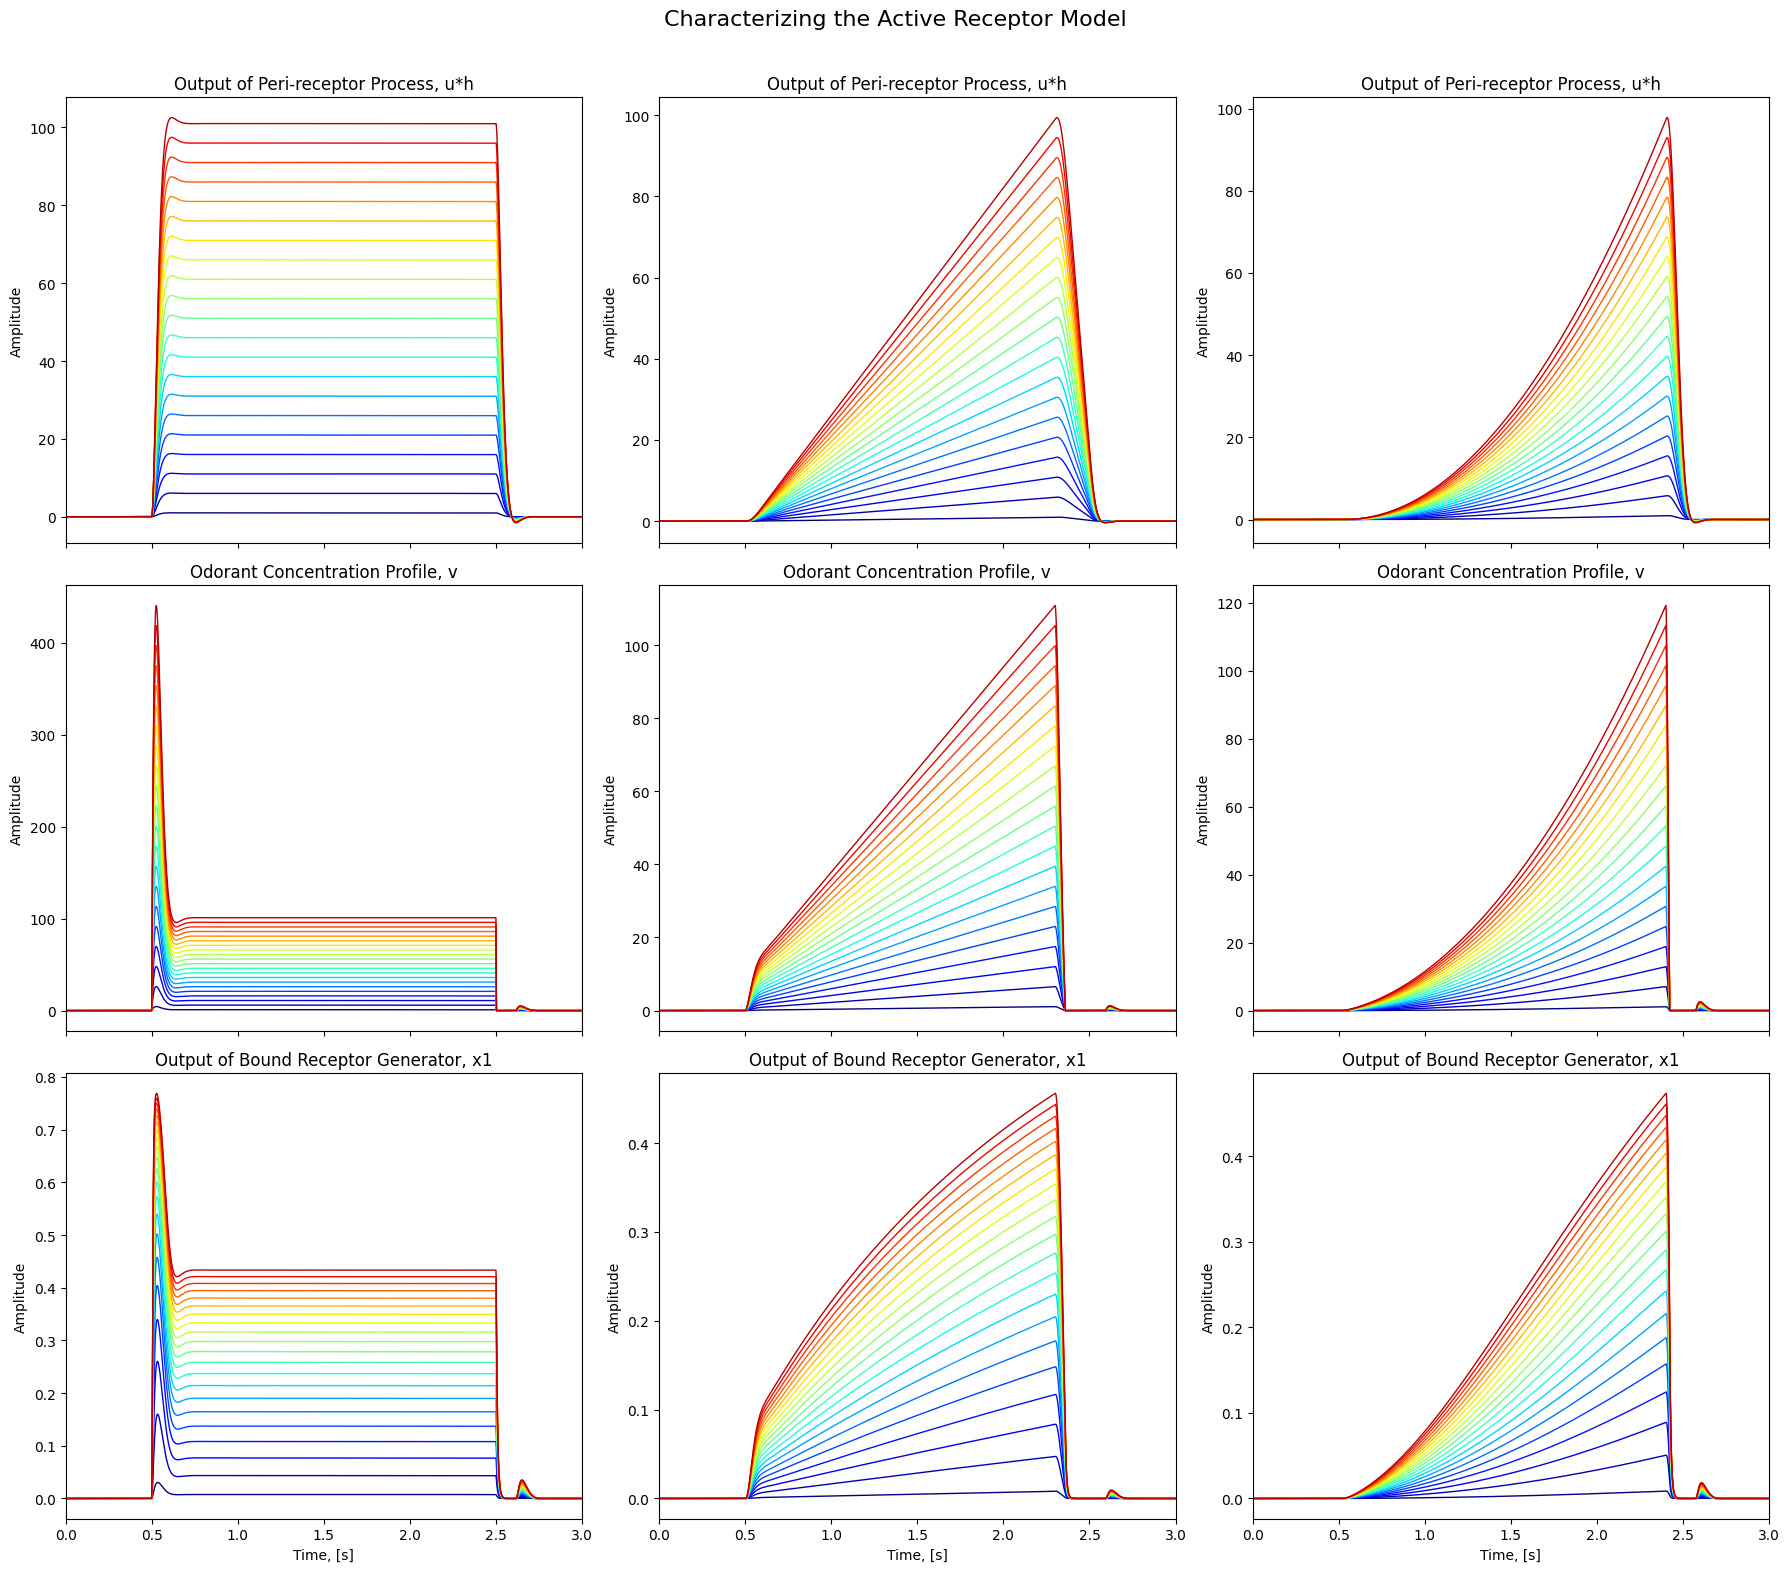

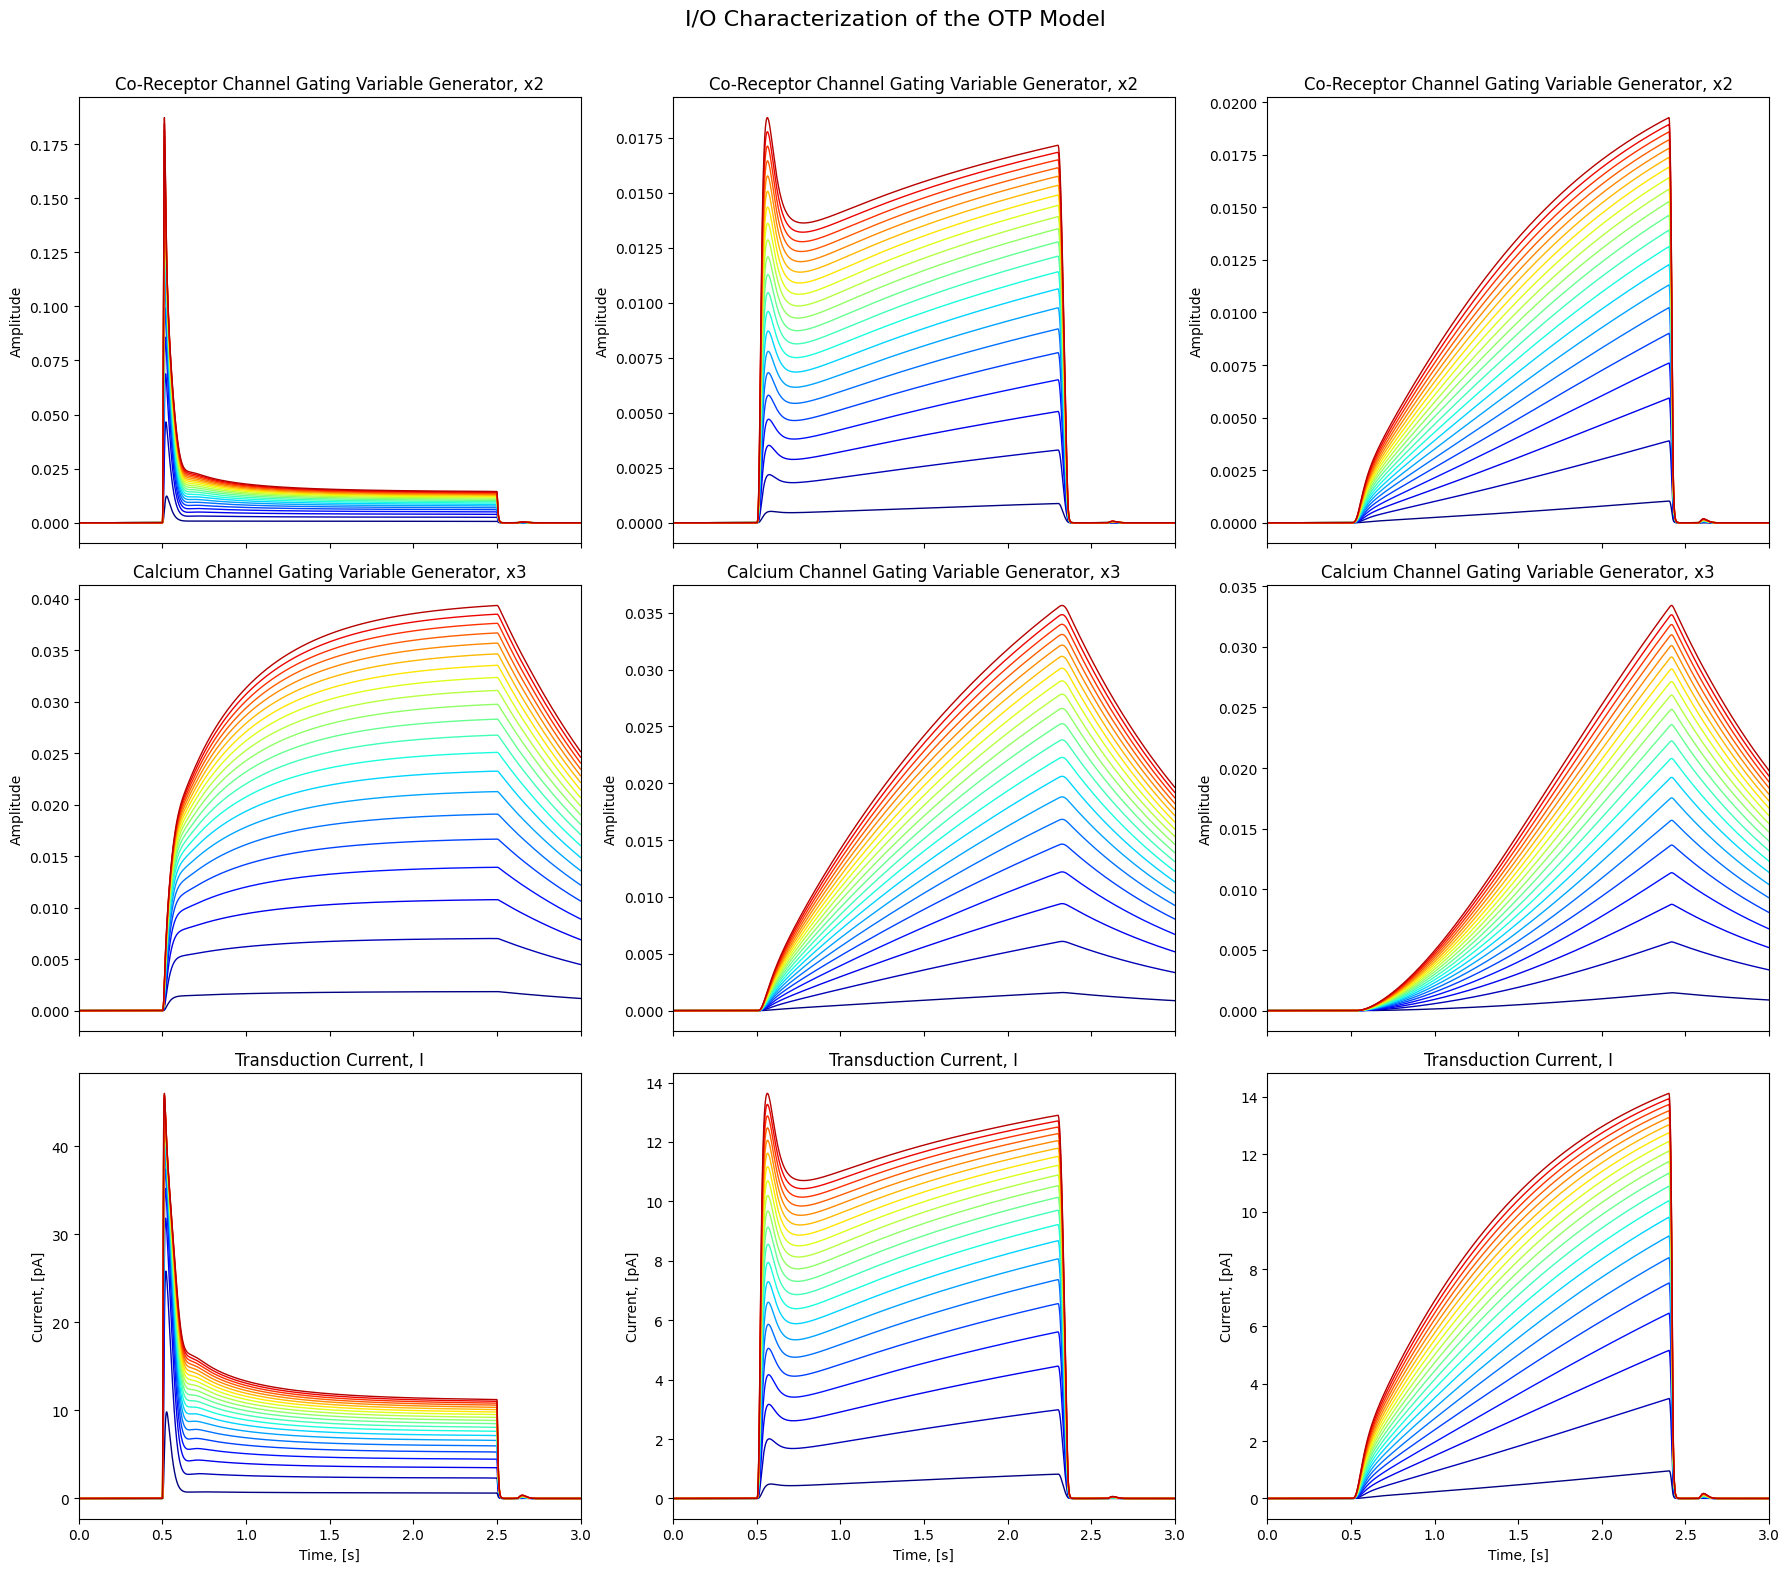

In [ ]:
#the plotting cell for the above OTP model

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# time axis + model setup
t_step = 1e-5
t_duration = 3.0
t_range = np.arange(0.0, t_duration, t_step)
R = 1
O = 1
N = 21

# skeleton code taken from
b_val = 1.0
d_val = 132.0

stimuli = ["step", "ramp", "parabola"]
cmap = plt.get_cmap("jet_r")

# fig  1
fig1, axes1 = plt.subplots(3, 3, figsize=(18, 16), sharex=True)

for k, stimulus in enumerate(stimuli):
    model = OTPModel()
    u = generate_stimulus(t_range, R, O, N, stimulus)
    u_h, v, x_1, x_2, x_3, I = model.sim(t_range, b_val, d_val, u)

    # Row 1 is u*h
    ax = axes1[0, k]
    for i in range(N):
        ax.plot(t_range, u_h[:, 0, 0, i], c=cmap(1.0 - float(i) / N), linewidth=1.0)
    ax.set_title(f"{stimulus.capitalize()} waveform")
    ax.set_ylabel("Amplitude")
    ax.set_xlim([0, t_duration])
    ax.set_title("Output of the Peri-receptor Process, u*h")

    # Row 2 is v
    ax = axes1[1, k]
    for i in range(N):
        ax.plot(t_range, v[:, 0, 0, i], c=cmap(1.0 - float(i) / N), linewidth=1.0)
    ax.set_ylabel("Amplitude")
    ax.set_xlim([0, t_duration])
    ax.set_title("the Odorant Concentration Profile, v")

    # and row 3 -> x1
    ax = axes1[2, k]
    for i in range(N):
        ax.plot(t_range, x_1[:, 0, 0, i], c=cmap(1.0 - float(i) / N), linewidth=1.0)
    ax.set_ylabel("Amplitude")
    ax.set_xlabel("Time, [in s]")
    ax.set_xlim([0, t_duration])
    ax.set_title("the Output of Bound Receptor Generator, x1")

fig1.suptitle("Characterizing the Active Receptor Model", fontsize=16)
fig1.tight_layout(rect=[0, 0, 1, 0.97])

# fig 2
fig2, axes2 = plt.subplots(3, 3, figsize=(18, 16), sharex=True)

for k, stimulus in enumerate(stimuli):
    model = OTPModel()
    u = generate_stimulus(t_range, R, O, N, stimulus)
    u_h, v, x_1, x_2, x_3, I = model.sim(t_range, b_val, d_val, u)

    # Row 1 -> x2
    ax = axes2[0, k]
    for i in range(N):
        ax.plot(t_range, x_2[:, 0, 0, i], c=cmap(1.0 - float(i) / N), linewidth=1.0)
    ax.set_ylabel("Amplitude")
    ax.set_xlim([0, t_duration])
    ax.set_title("The Co-Receptor Channel Gating Variable Generator, x2")

    # Row 2 -> x3
    ax = axes2[1, k]
    for i in range(N):
        ax.plot(t_range, x_3[:, 0, 0, i], c=cmap(1.0 - float(i) / N), linewidth=1.0)
    ax.set_ylabel("Amplitude")
    ax.set_xlim([0, t_duration])
    ax.set_title("The Calcium Channel Gating Variable Generator, x3")

    # Row 3 -> I
    ax = axes2[2, k]
    for i in range(N):
        ax.plot(t_range, I[:, 0, 0, i], c=cmap(1.0 - float(i) / N), linewidth=1.0)
    ax.set_ylabel("Current, [in pA]")
    ax.set_xlabel("Time, [s]")
    ax.set_xlim([0, t_duration])
    ax.set_title("Transduction Current, I")

fig2.suptitle("I/O Characterization of the OTP Model", fontsize=16)
fig2.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()


**(4) I/O Characterization of the Hodgkin-Huxley Neuron (HH Model), Lec-
ture #8, slide #57, 2D plot on the right. Compare the I/O character-
ization of HH and CS models and comment on your observation.**

(Part 1)


In [ ]:

#the first cell that is going to define the neuron model
#

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import copy

n_neurons = 50  #this is the same as original notebook cell


def zo(x):
    """
    make sure that we're going to clip the gating/state variables
    into [0, 1], since that was what was suggested by the handout.
    """
    return np.minimum(np.maximum(0.0, x), 1.0)


def CS_step(dt, I, x): #follows the og homework skeleton code
    # s to ms
    dt = dt * 1000.0

    # we have that the original cell passes I as a list/array-like quantity in some places
    if np.isscalar(I):
        I_inj = I
    else:
        I_inj = I[0]

    V, n, m, h, a, b, spike, Vprev1, Vprev2 = x

    # these are all of our parameters from the original homework cell
    E_K = -72.0
    E_Na = 55.0
    E_a = -75.0
    E_l = -17.0
    G_total = 67.7
    G_a = 47.7
    G_Na = 120.0
    G_K = G_total - G_a
    G_l = 0.3
    ms = -5.3
    hs = -12.0
    ns = -4.3

    # and then lets also keep the noise scale that was used in the og cell
    w_c = 2.05

    #all of this code corresponds to the channel kinetics
    #that were obtained from the original homework cell.
    a_m = -0.1 * (V + 35.0 + ms) / (np.exp(-(V + 35.0 + ms) / 10.0) - 1.0)
    b_m = 4.0 * np.exp(-(V + 60.0 + ms) / 18.0)
    m_inf = a_m / (a_m + b_m)
    tau_m = 1.0 / (3.8 * (a_m + b_m))

    a_h = 0.07 * np.exp(-(V + 60.0 + hs) / 20.0)
    b_h = 1.0 / (1.0 + np.exp(-(V + 30.0 + hs) / 10.0))
    h_inf = a_h / (a_h + b_h)
    tau_h = 1.0 / (3.8 * (a_h + b_h))

    a_n = -0.01 * (V + 50.0 + ns) / (np.exp(-(V + 50.0 + ns) / 10.0) - 1.0)
    b_n = 0.125 * np.exp(-(V + 60.0 + ns) / 80.0)
    n_inf = a_n / (a_n + b_n)
    tau_n = 2.0 / (3.8 * (a_n + b_n))

    a_inf = (0.0761 * np.exp((V + 94.22) / 31.84) / (1.0 + np.exp((V + 1.17) / 28.93))) ** 0.3333
    tau_a = 0.3632 + 1.158 / (1.0 + np.exp((V + 55.96) / 20.12))

    b_inf = (1.0 / (1.0 + np.exp((V + 53.3) / 14.54))) ** 4.0
    tau_b = 1.24 + 2.678 / (1.0 + np.exp((V + 50.0) / 16.027))

    # our odes :(
    dV = (
        I_inj
        - G_l * (V - E_l)
        - G_Na * h * m * m * m * (V - E_Na)
        - G_K * n * n * n * n * (V - E_K)
        - G_a * b * a * a * a * (V - E_a)
    )
    dm = (m_inf - m) / tau_m
    dh = (h_inf - h) / tau_h
    dn = (n_inf - n) / tau_n
    da = (a_inf - a) / tau_a
    db = (b_inf - b) / tau_b

    # all of the noise terms, making sure that were keeping the original structure
    if not np.isscalar(V):
        wV = w_c * np.random.randn(V.shape[0], V.shape[1])
        wn = w_c * np.random.randn(V.shape[0], V.shape[1])
        wm = w_c * np.random.randn(V.shape[0], V.shape[1])
        wh = w_c * np.random.randn(V.shape[0], V.shape[1])
        wa = w_c * np.random.randn(V.shape[0], V.shape[1])
        wb = w_c * np.random.randn(V.shape[0], V.shape[1])
    else:
        wV = w_c * np.random.randn()
        wn = w_c * np.random.randn()
        wm = w_c * np.random.randn()
        wh = w_c * np.random.randn()
        wa = w_c * np.random.randn()
        wb = w_c * np.random.randn()

    Vnew = V + dt * (wV + dV)

    #the same spike detector logic as original cell
    spike = (Vprev2 <= Vprev1) * (Vprev1 >= Vnew) * (Vprev1 > -30.0)

    x_new = [
        Vnew,
        zo(n + dt * (dn + wn)),
        zo(m + dt * (dm + wm)),
        zo(h + dt * (dh + wh)),
        zo(a + dt * (da + wa)),
        zo(b + dt * (db + wb)),
        spike,
        V,
        Vprev1,
    ]
    return x_new


def HH_step(dt, I, x):
    """
    lets make just one Euler step for the Hodgkin-Huxley neuron.
    State x contains:
        [V, n, m, h, spike, Vprev1, Vprev2]
    """
    dt = dt * 1000.0
    if np.isscalar(I):
        I_inj = I
    else:
        I_inj = I[0]

    # fix for the og broken code
    # then lets make the provided x directly
    V, n, m, h, spike, Vprev1, Vprev2 = x
    n = zo(n)
    m = zo(m)
    h = zo(h)

    #the standard HH constants exactly that we can find in the original homework cell
    E_K = -77.0
    E_Na = 50.0
    E_L = -54.387

    gmax_K = 36.0
    gmax_Na = 120.0
    g_L = 0.3

    an = 0.01 * (V + 55.0) / (1.0 - np.exp(-0.1 * (V + 55.0)))
    bn = 0.125 * np.exp(-(V + 65.0) / 80.0)

    am = 0.1 * (V + 40.0) / (1.0 - np.exp(-0.1 * (V + 40.0)))
    bm = 4.0 * np.exp(-(V + 65.0) / 18.0)

    ah = 0.07 * np.exp(-0.05 * (V + 65.0))
    bh = 1.0 / (1.0 + np.exp(-0.1 * (V + 35.0)))

    # our og gating dynamics
    dn = an * (1.0 - n) - bn * n
    dm = am * (1.0 - m) - bm * m
    dh = ah * (1.0 - h) - bh * h

    # conductance
    g_K = gmax_K * (n ** 4.0)
    g_Na = gmax_Na * (m ** 3.0) * h

    # I
    I_K = g_K * (V - E_K)
    I_Na = g_Na * (V - E_Na)
    I_L = g_L * (V - E_L)

    # our voltage update
    dV = I_inj - I_K - I_Na - I_L
    Vnew = V + dt * dV

    # lets try to keep the the spike detector structure aligned with og cell
    spike = (Vprev2 <= Vprev1) * (Vprev1 >= Vnew) * (Vprev1 > -30.0)
    x_new = [
        Vnew,
        zo(n + dt * dn),
        zo(m + dt * dm),
        zo(h + dt * dh),
        spike,
        V,
        Vprev1,
    ]
    return x_new


**(4) I/O Characterization of the Hodgkin-Huxley Neuron (HH Model), Lec-
ture #8, slide #57, 2D plot on the right. Compare the I/O character-
ization of HH and CS models and comment on your observation.**

(Part 2)


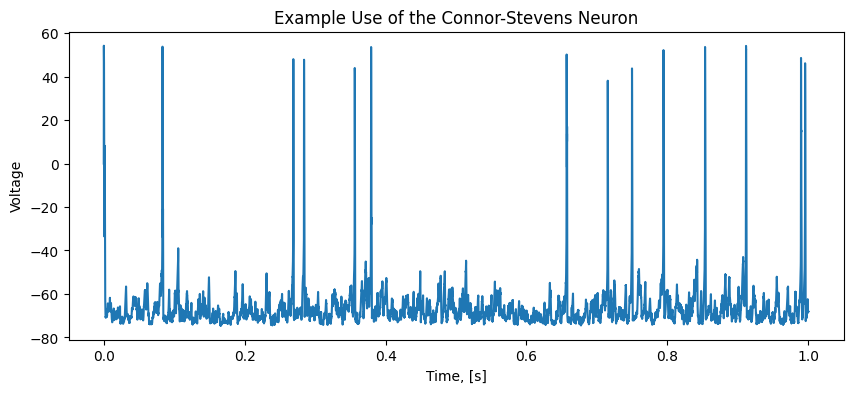

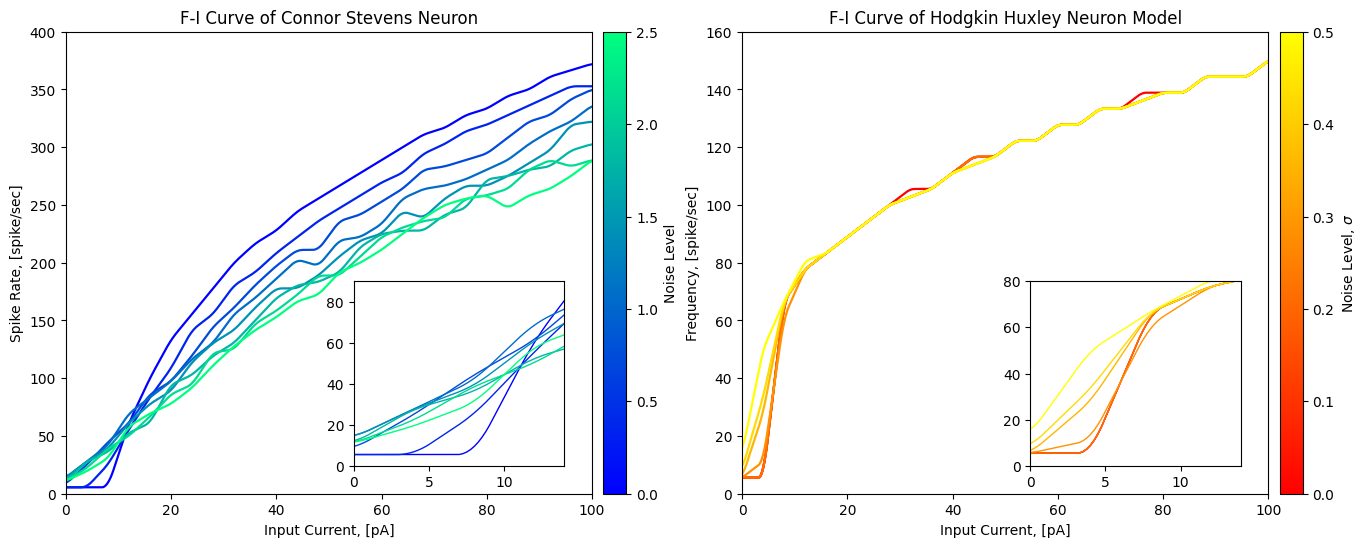

In [ ]:


#test and charactarize the our neuron models
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# from the handout basically
def count_spikes_with_refractory(spike_series, dt, refractory_ms=1.0):
    refractory_steps = int(round((refractory_ms / 1000.0) / dt))
    count = 0
    last_spike_idx = -refractory_steps - 1
    for k, s in enumerate(spike_series):
        if s and (k - last_spike_idx > refractory_steps):
            count += 1
            last_spike_idx = k
    return count

"""
# this should hopefully contain the display-only smoothing so curves
#so that they look more lecture-like
# while keeping the simulation more managible: was taking an absurd amount of time
#to run \
"""
def smooth_display_curve(x, y, x_dense=None, window=7):
    if x_dense is None:
        x_dense = np.linspace(x.min(), x.max(), 400)
    y_interp = np.interp(x_dense, x, y)

    if window <= 1:
        return x_dense, y_interp

    kernel = np.ones(window) / window
    pad = window // 2
    y_pad = np.pad(y_interp, (pad, pad), mode="edge")
    y_smooth = np.convolve(y_pad, kernel, mode="valid")
    return x_dense, y_smooth


#references hw skeleton
def CS_step_sigma(dt, I, x, sigma):
    dt = dt * 1000.0

    if np.isscalar(I):
        I_inj = I
    else:
        I_inj = I[0]

    V, n, m, h, a, b, spike, Vprev1, Vprev2 = x
    E_K = -72.0
    E_Na = 55.0
    E_a = -75.0
    E_l = -17.0
    G_total = 67.7
    G_a = 47.7
    G_Na = 120.0
    G_K = G_total - G_a
    G_l = 0.3
    ms = -5.3
    hs = -12.0
    ns = -4.3
    a_m = -0.1 * (V + 35 + ms) / (np.exp(-(V + 35 + ms) / 10) - 1)
    b_m = 4 * np.exp(-(V + 60 + ms) / 18)
    m_inf = a_m / (a_m + b_m)
    tau_m = 1 / (3.8 * (a_m + b_m))

    a_h = 0.07 * np.exp(-(V + 60 + hs) / 20)
    b_h = 1 / (1 + np.exp(-(V + 30 + hs) / 10))
    h_inf = a_h / (a_h + b_h)
    tau_h = 1 / (3.8 * (a_h + b_h))

    a_n = -0.01 * (V + 50 + ns) / (np.exp(-(V + 50 + ns) / 10) - 1)
    b_n = 0.125 * np.exp(-(V + 60 + ns) / 80)
    n_inf = a_n / (a_n + b_n)
    tau_n = 2 / (3.8 * (a_n + b_n))

    a_inf = (0.0761 * np.exp((V + 94.22) / 31.84) / (1 + np.exp((V + 1.17) / 28.93))) ** 0.3333
    tau_a = 0.3632 + 1.158 / (1 + np.exp((V + 55.96) / 20.12))
    b_inf = (1 / (1 + np.exp((V + 53.3) / 14.54))) ** 4
    tau_b = 1.24 + 2.678 / (1 + np.exp((V + 50) / 16.027))

    dV = (
        I_inj
        - G_l * (V - E_l)
        - G_Na * h * m * m * m * (V - E_Na)
        - G_K * n * n * n * n * (V - E_K)
        - G_a * b * a * a * a * (V - E_a)
    )
    dm = (m_inf - m) / tau_m
    dh = (h_inf - h) / tau_h
    dn = (n_inf - n) / tau_n
    da = (a_inf - a) / tau_a
    db = (b_inf - b) / tau_b

    wV = sigma * np.random.randn()
    wn = sigma * np.random.randn()
    wm = sigma * np.random.randn()
    wh = sigma * np.random.randn()
    wa = sigma * np.random.randn()
    wb = sigma * np.random.randn()

    Vnew = V + dt * (wV + dV)
    spike = (Vprev2 <= Vprev1) * (Vprev1 >= Vnew) * (Vprev1 > -30)

    return [
        Vnew,
        zo(n + dt * (dn + wn)),
        zo(m + dt * (dm + wm)),
        zo(h + dt * (dh + wh)),
        zo(a + dt * (da + wa)),
        zo(b + dt * (db + wb)),
        spike,
        V,
        Vprev1,
    ]

def HH_step_fixed(dt, I, x):
    dt = dt * 1000.0

    if np.isscalar(I):
        I_inj = I
    else:
        I_inj = I[0]

    V, n, m, h, spike, Vprev1, Vprev2 = x

    n = zo(n)
    m = zo(m)
    h = zo(h)

    E_K = -77.0
    E_Na = 50.0
    E_L = -54.387
    gmax_K = 36.0
    gmax_Na = 120.0
    g_L = 0.3

    an = 0.01 * (V + 55) / (1 - np.exp(-0.1 * (V + 55)))
    bn = 0.125 * np.exp(-(V + 65) / 80)

    am = 0.1 * (V + 40) / (1 - np.exp(-0.1 * (V + 40)))
    bm = 4 * np.exp(-(V + 65) / 18)

    ah = 0.07 * np.exp(-0.05 * (V + 65))
    bh = 1 / (1 + np.exp(-0.1 * (V + 35)))

    dn = an * (1 - n) - bn * n
    dm = am * (1 - m) - bm * m
    dh = ah * (1 - h) - bh * h

    g_K = gmax_K * (n ** 4)
    g_Na = gmax_Na * (m ** 3) * h

    I_K = g_K * (V - E_K)
    I_Na = g_Na * (V - E_Na)
    I_L = g_L * (V - E_L)

    dV = I_inj - I_K - I_Na - I_L
    Vnew = V + dt * dV

    spike = (Vprev2 <= Vprev1) * (Vprev1 >= Vnew) * (Vprev1 > -30)

    return [
        Vnew,
        zo(n + dt * dn),
        zo(m + dt * dm),
        zo(h + dt * dh),
        spike,
        V,
        Vprev1,
    ]


# now these are our simulators
def simulate_cs_constant_current(I_inj, dt, T, sigma=0.0, seed=None):
    if seed is not None:
        np.random.seed(seed)

    n_steps = int(round(T / dt))
    x_cs = [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]
    V_trace = np.zeros(n_steps)
    spike_trace = np.zeros(n_steps, dtype=bool)

    for k in range(n_steps):
        x_cs = CS_step_sigma(dt, [I_inj], x_cs, sigma=sigma)
        V_trace[k] = x_cs[0]
        spike_trace[k] = bool(x_cs[6])

    return V_trace, spike_trace


def simulate_hh_constant_current(I_inj, dt, T, sigma=0.0, seed=None, hh_input_noise_scale=24.0):
    if seed is not None:
        np.random.seed(seed)

    n_steps = int(round(T / dt))
    x_hh = [0.0, 0.3178, 0.0530, 0.5958, 0.0, 0.0, 0.0]
    V_trace = np.zeros(n_steps)
    spike_trace = np.zeros(n_steps, dtype=bool)

    for k in range(n_steps):
        # the noise enters from the input current only
        I_eff = max(0.0, I_inj + hh_input_noise_scale * sigma * np.random.randn())
        x_hh = HH_step_fixed(dt, [I_eff], x_hh)
        V_trace[k] = x_hh[0]
        spike_trace[k] = bool(x_hh[4])

    return V_trace, spike_trace


'''
this cell is going to take a mean rate over some small number of trials
not too many data points but not too few either.
'''

def mean_rate_over_trials(model_name, I_inj, dt, T, sigma, n_trials=2):
    rates = []
    for trial in range(n_trials):
        if model_name == "CS":
            _, spike_trace = simulate_cs_constant_current(I_inj, dt, T, sigma=sigma, seed=trial)
        elif model_name == "HH":
            _, spike_trace = simulate_hh_constant_current(I_inj, dt, T, sigma=sigma, seed=trial)
        else:
            raise ValueError("wrong model")

        rate = count_spikes_with_refractory(spike_trace, dt, refractory_ms=1.0) / T
        rates.append(rate)

    return np.mean(rates)


# cs model plot
t_step = 1e-5
T_trace = 1.0

V_cs_example, spikes_cs_example = simulate_cs_constant_current(
    I_inj=1.0, dt=t_step, T=T_trace, sigma=2.05, seed=0
)

t_axis_trace = np.arange(len(V_cs_example)) * t_step

plt.figure(figsize=(10, 4))
plt.plot(t_axis_trace, V_cs_example)
plt.xlabel("Time, [in s]")
plt.ylabel("Voltage")
plt.title("Example use case for the Connor-Stevens Neuron")
plt.show()

'''
this is the f-1  characterization
makes a comprimise where there is a small dt preserved and also a
corser stimulation grid, w only 2 trials per point, so the whole
thing won't run quite as long (around 40 mins)
'''
T_fi = 0.18
currents_eval = np.arange(0.0, 101.0, 4.0)
cs_sigmas = np.linspace(0.0, 2.5, 8)
hh_sigmas = np.linspace(0.0, 0.5, 8)
n_trials_per_point = 2

cs_rates = np.zeros((len(cs_sigmas), len(currents_eval)))
hh_rates = np.zeros((len(hh_sigmas), len(currents_eval)))
for i, sigma in enumerate(cs_sigmas):
    for j, I_inj in enumerate(currents_eval):
        cs_rates[i, j] = mean_rate_over_trials(
            "CS", I_inj, t_step, T_fi, sigma, n_trials=n_trials_per_point
        )

for i, sigma in enumerate(hh_sigmas):
    for j, I_inj in enumerate(currents_eval):
        hh_rates[i, j] = mean_rate_over_trials(
            "HH", I_inj, t_step, T_fi, sigma, n_trials=n_trials_per_point
        )

#plotting chat enabled
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CS plot
cmap_cs = plt.get_cmap("winter")
norm_cs = Normalize(vmin=cs_sigmas.min(), vmax=cs_sigmas.max())

for sigma, rates in zip(cs_sigmas, cs_rates):
    x_dense, y_smooth = smooth_display_curve(currents_eval, rates, window=9)
    axes[0].plot(x_dense, y_smooth, color=cmap_cs(norm_cs(sigma)), linewidth=1.6)

axes[0].set_title("the F-I Curve of Connor Stevens Neuron")
axes[0].set_xlabel("Input Current, [ in pA]")
axes[0].set_ylabel("Spike Rate, [ in spike/sec]")
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 400)

axins0 = inset_axes(axes[0], width="40%", height="40%", loc="lower right", borderpad=2)
for sigma, rates in zip(cs_sigmas, cs_rates):
    x_dense, y_smooth = smooth_display_curve(currents_eval, rates, window=9)
    axins0.plot(x_dense, y_smooth, color=cmap_cs(norm_cs(sigma)), linewidth=1.0)
axins0.set_xlim(0, 14)
axins0.set_ylim(0, 90)

sm_cs = ScalarMappable(norm=norm_cs, cmap=cmap_cs)
sm_cs.set_array([])
cbar0 = fig.colorbar(sm_cs, ax=axes[0], fraction=0.046, pad=0.02)
cbar0.set_label("Noise Level")

# the hh model panel
cmap_hh = plt.get_cmap("autumn") #pretty
norm_hh = Normalize(vmin=hh_sigmas.min(), vmax=hh_sigmas.max())

for sigma, rates in zip(hh_sigmas, hh_rates):
    x_dense, y_smooth = smooth_display_curve(currents_eval, rates, window=7)
    axes[1].plot(x_dense, y_smooth, color=cmap_hh(norm_hh(sigma)), linewidth=1.6)

axes[1].set_title("the F-I Curve of Hodgkin Huxley Neuron Model")
axes[1].set_xlabel("Input Current, [in pA]")
axes[1].set_ylabel("Frequency, [in spike/sec]")
axes[1].set_xlim(0, 100)
axes[1].set_ylim(0, 160)

axins1 = inset_axes(axes[1], width="40%", height="40%", loc="lower right", borderpad=2)
for sigma, rates in zip(hh_sigmas, hh_rates):
    x_dense, y_smooth = smooth_display_curve(currents_eval, rates, window=7)
    axins1.plot(x_dense, y_smooth, color=cmap_hh(norm_hh(sigma)), linewidth=1.0)
axins1.set_xlim(0, 14)
axins1.set_ylim(0, 80)

sm_hh = ScalarMappable(norm=norm_hh, cmap=cmap_hh)
sm_hh.set_array([])
cbar1 = fig.colorbar(sm_hh, ax=axes[1], fraction=0.046, pad=0.02)
cbar1.set_label(r"Noise Level, $\sigma$")

plt.show()

Compare the I/O characterization of HH and CS models and comment on your observation.

We believe that the input–output (F–I) characteristics that are discernable in the Connor–Stevens (CS) and Hodgkin–Huxley (HH) neuron models show a few important differences in how they transform input current into the spike rate. In particular, we find that the CS model produces a smoother and more gradual increase in firing rate as the input current increases, which is especially noticeable near the threshold. In contrast, the opposing HH model exhibits much stronger threshold behavior, with a sharper transition from no spiking to sustained firing once we see that the input current exceeds a certain critical value.

As for the low input currents, we noticed that the CS model is able to generate some of these low firing rates more continuously, while the HH model, more often than not, tends to remain silent until the input current crosses a certain threshold. To us, this indicates that the CS neuron has greater sensitivity to weak inputs and also is able to provide a more graded representation of small changes in the intensity of the stimulus. The HH neuron behaves more like a sort of threshold detector, whereas the CS neuron continuously varies firing rate, even at low input levels.

At higher input currents, we can observe that both of the models are able to produce an increasing firing rate with increasing current. With that said however, the CS model reaches higher firing rates than the HH model. Importantly, at low input currents, CS neuron firing is much less noise-dependent compared to HH.



**(5) I/O Characterization of the OTP/BSG Cascade, An Example: Re-
sponse to Step, Ramp and Parabola Stimuli, Lecture #9, slide 17. Simulate and compare both CS and HH models; comment on
your observation.**

(Part 1)


In [ ]:

'''
this cell is going to be the one that makes the otp and the bsg cascade for the
steo, the ramop and the parabola stimuli
its going to have some updated functinality with the 1ms refractory period, and
the runtime is going to be acconuting for - shooting for something around the
15 minute mark
'''

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

#these are our lecture grounded params
#for Acetone-Or59b

#found on page 47
b_otp = 2.17e-2
d_otp = 2.94

# setup for our simulation
t_step = 1e-5
t_duration = 3.0
t_range = np.arange(0.0, t_duration, t_step)
R = 1
O = 1
N = 21
c_vals = np.arange(1.0, 102.0, 5.0)
# Keep this moderate so runtime stays reasonable.
#not going to be increasing any time soon.
n_bsg_neurons = 6

bin_size = 0.020#20 ms
bin_shift = 0.010 #10 ms

# helper functions
def _safe_div(num, den, eps=1e-12):
    den = np.where(np.abs(den) < eps, eps, den)
    return num / den

def _compute_psth(spikes, dt, bin_size=0.020, bin_shift=0.010):
    Tn, Namp, M = spikes.shape
    bin_steps = int(round(bin_size / dt))
    shift_steps = int(round(bin_shift / dt))
    starts = np.arange(0, Tn - bin_steps + 1, shift_steps)

    psth = np.zeros((len(starts), Namp), dtype=float)
    for i, s in enumerate(starts):
        counts = spikes[s:s + bin_steps].sum(axis=(0, 2))
        psth[i] = counts / (M * bin_size)

    t_psth = (starts + bin_steps / 2) * dt
    return t_psth, psth

#cs population sim w/the 1ms refractory times.
def simulate_cs_population(I_t, dt, n_neurons=6, sigma=0.85, seed=0):
    """
    here we have the I_t shape: [T, Namp]
    and then that is going to return a spikes shape something like [T, Namp, n_neurons]
    """
    rng = np.random.default_rng(seed)

    Tn, Namp = I_t.shape
    M = n_neurons

    #this is a small fixed gain variation -> reduce some artifical synchrony
    gain = np.clip(1.0 + 0.05 * rng.standard_normal((Namp, M)), 0.85, 1.15)
    I_pop = I_t[:, :, None] * gain[None, :, :]

    #init states
    V = 0.5 * rng.standard_normal((Namp, M))
    n = np.zeros((Namp, M))
    m = np.zeros((Namp, M))
    h = np.ones((Namp, M))
    a = np.zeros((Namp, M))
    b = np.zeros((Namp, M))

    Vprev1 = V.copy()
    Vprev2 = V.copy()

    spikes = np.zeros((Tn, Namp, M), dtype=np.uint8)

    #seen this all before
    dt_ms = dt * 1000.0
    E_K  = -72.0
    E_Na =  55.0
    E_a  = -75.0
    E_l  = -17.0
    G_total = 67.7
    G_a  = 47.7
    G_Na = 120.0
    G_K  = G_total - G_a
    G_l  = 0.3

    ms = -5.3
    hs = -12.0
    ns = -4.3

    refractory_steps = int(round(1e-3 / dt))
    ref_count = np.zeros((Namp, M), dtype=np.int32)

    for k in range(Tn):
        a_m = -0.1 * (V + 35.0 + ms) / (np.exp(-(V + 35.0 + ms) / 10.0) - 1.0)
        b_m = 4.0 * np.exp(-(V + 60.0 + ms) / 18.0)
        m_inf = _safe_div(a_m, a_m + b_m)
        tau_m = _safe_div(1.0, 3.8 * (a_m + b_m))

        a_h = 0.07 * np.exp(-(V + 60.0 + hs) / 20.0)
        b_h = 1.0 / (1.0 + np.exp(-(V + 30.0 + hs) / 10.0))
        h_inf = _safe_div(a_h, a_h + b_h)
        tau_h = _safe_div(1.0, 3.8 * (a_h + b_h))

        a_n = -0.01 * (V + 50.0 + ns) / (np.exp(-(V + 50.0 + ns) / 10.0) - 1.0)
        b_n = 0.125 * np.exp(-(V + 60.0 + ns) / 80.0)
        n_inf = _safe_div(a_n, a_n + b_n)
        tau_n = _safe_div(2.0, 3.8 * (a_n + b_n))

        a_inf = (0.0761 * np.exp((V + 94.22) / 31.84) / (1.0 + np.exp((V + 1.17) / 28.93))) ** 0.3333
        tau_a = 0.3632 + 1.158 / (1.0 + np.exp((V + 55.96) / 20.12))

        b_inf = (1.0 / (1.0 + np.exp((V + 53.3) / 14.54))) ** 4.0
        tau_b = 1.24 + 2.678 / (1.0 + np.exp((V + 50.0) / 16.027))

        dV = (
            I_pop[k]
            - G_l * (V - E_l)
            - G_Na * h * (m ** 3) * (V - E_Na)
            - G_K * (n ** 4) * (V - E_K)
            - G_a * b * (a ** 3) * (V - E_a)
        )

        dm = (m_inf - m) / tau_m
        dh = (h_inf - h) / tau_h
        dn = (n_inf - n) / tau_n
        da = (a_inf - a) / tau_a
        db = (b_inf - b) / tau_b

        # this is some moderate noise, should be smaller than before
        Vnew = V + dt_ms * (dV + sigma * rng.standard_normal((Namp, M)))

        #the detector to find the peak
        raw_spike = (Vprev2 <= Vprev1) & (Vprev1 >= Vnew) & (Vprev1 > -30.0)

        #and then this is going to be the 1 ms refractory
        valid_spike = raw_spike & (ref_count <= 0)
        spikes[k] = valid_spike.astype(np.uint8)

        ref_count = np.maximum(ref_count - 1, 0)
        ref_count[valid_spike] = refractory_steps

        Vprev2 = Vprev1.copy()
        Vprev1 = V.copy()
        V = Vnew
        n = np.clip(n + dt_ms * (dn + 0.20 * sigma * rng.standard_normal((Namp, M))), 0.0, 1.0)
        m = np.clip(m + dt_ms * (dm + 0.20 * sigma * rng.standard_normal((Namp, M))), 0.0, 1.0)
        h = np.clip(h + dt_ms * (dh + 0.20 * sigma * rng.standard_normal((Namp, M))), 0.0, 1.0)
        a = np.clip(a + dt_ms * (da + 0.20 * sigma * rng.standard_normal((Namp, M))), 0.0, 1.0)
        b = np.clip(b + dt_ms * (db + 0.20 * sigma * rng.standard_normal((Namp, M))), 0.0, 1.0)

    return spikes
# hh population sim
# includes something of a tiny input jitter so that we avoid perfectly synchronized traces
#mentioned above
def simulate_hh_population(I_t, dt, n_neurons=6, input_sigma=0.04, seed=0):
    rng = np.random.default_rng(seed)

    Tn, Namp = I_t.shape
    M = n_neurons

    gain = np.clip(1.0 + 0.06 * rng.standard_normal((Namp, M)), 0.85, 1.15)
    I_pop = I_t[:, :, None] * gain[None, :, :]

    V = 0.5 * rng.standard_normal((Namp, M))
    n = np.full((Namp, M), 0.3178)
    m = np.full((Namp, M), 0.0530)
    h = np.full((Namp, M), 0.5958)

    Vprev1 = V.copy()
    Vprev2 = V.copy()

    spikes = np.zeros((Tn, Namp, M), dtype=np.uint8)

    dt_ms = dt * 1000.0

    E_K  = -77.0
    E_Na =  50.0
    E_L  = -54.387
    gK  = 36.0
    gNa = 120.0
    gL  = 0.3
    refractory_steps = int(round(1e-3 / dt))
    ref_count = np.zeros((Namp, M), dtype=np.int32)

    for k in range(Tn):
        Ieff = np.maximum(
            0.0,
            I_pop[k] + 10.0 * input_sigma * rng.standard_normal((Namp, M))
        )

        a_n = 0.01 * (V + 55.0) / (1.0 - np.exp(-0.1 * (V + 55.0)))
        b_n = 0.125 * np.exp(-(V + 65.0) / 80.0)

        a_m = 0.1 * (V + 40.0) / (1.0 - np.exp(-0.1 * (V + 40.0)))
        b_m = 4.0 * np.exp(-(V + 65.0) / 18.0)

        a_h = 0.07 * np.exp(-0.05 * (V + 65.0))
        b_h = 1.0 / (1.0 + np.exp(-0.1 * (V + 35.0)))

        dn = a_n * (1.0 - n) - b_n * n
        dm = a_m * (1.0 - m) - b_m * m
        dh = a_h * (1.0 - h) - b_h * h

        I_K  = gK * (n ** 4) * (V - E_K)
        I_Na = gNa * (m ** 3) * h * (V - E_Na)
        I_L  = gL * (V - E_L)

        dV = Ieff - I_K - I_Na - I_L
        Vnew = V + dt_ms * dV

        raw_spike = (Vprev2 <= Vprev1) & (Vprev1 >= Vnew) & (Vprev1 > -30.0)

        # also adding a 1 ms refractory here too, for consistencies sake
        valid_spike = raw_spike & (ref_count <= 0)
        spikes[k] = valid_spike.astype(np.uint8)

        ref_count = np.maximum(ref_count - 1, 0)
        ref_count[valid_spike] = refractory_steps

        Vprev2 = Vprev1.copy()
        Vprev1 = V.copy()
        V = Vnew

        n = np.clip(n + dt_ms * dn, 0.0, 1.0)
        m = np.clip(m + dt_ms * dm, 0.0, 1.0)
        h = np.clip(h + dt_ms * dh, 0.0, 1.0)

    return spikes

#this is going to actually Run the OTP -> BSG cascade
otp_bsg_results = {"CS": {}, "HH": {}}
stimuli = ["step", "ramp", "parabola"]

for stimulus in stimuli:
    print(f"Running {stimulus}...")

    u = generate_stimulus(t_range, R, O, N, stimulus)
    model = OTPModel()
    _, _, _, _, _, I = model.sim(t_range, b_otp, d_otp, u)

    #the shape [T, 21]
    I_drive = I[:, 0, 0, :]

    spikes_cs = simulate_cs_population(
        I_drive, t_step,
        n_neurons=n_bsg_neurons,
        sigma=0.85,
        seed=1
    )
    t_psth_cs, psth_cs = _compute_psth(spikes_cs, t_step, bin_size, bin_shift)

    spikes_hh = simulate_hh_population(
        I_drive, t_step,
        n_neurons=n_bsg_neurons,
        input_sigma=0.04,
        seed=2
    )
    t_psth_hh, psth_hh = _compute_psth(spikes_hh, t_step, bin_size, bin_shift)

    otp_bsg_results["CS"][stimulus] = {
        "u": u[:, 0, 0, :],
        "I": I_drive,
        "t_psth": t_psth_cs,
        "psth": psth_cs
    }

    otp_bsg_results["HH"][stimulus] = {
        "u": u[:, 0, 0, :],
        "I": I_drive,
        "t_psth": t_psth_hh,
        "psth": psth_hh
    }
#just included some debugging prints
print("Cell 8 done.")

Running step...
Running ramp...
Running parabola...
Cell 8 done.




**(5) I/O Characterization of the OTP/BSG Cascade, An Example: Re-
sponse to Step, Ramp and Parabola Stimuli, Lecture #9, slide 17. Simulate and compare both CS and HH models; comment on
your observation.**

(Part 2)


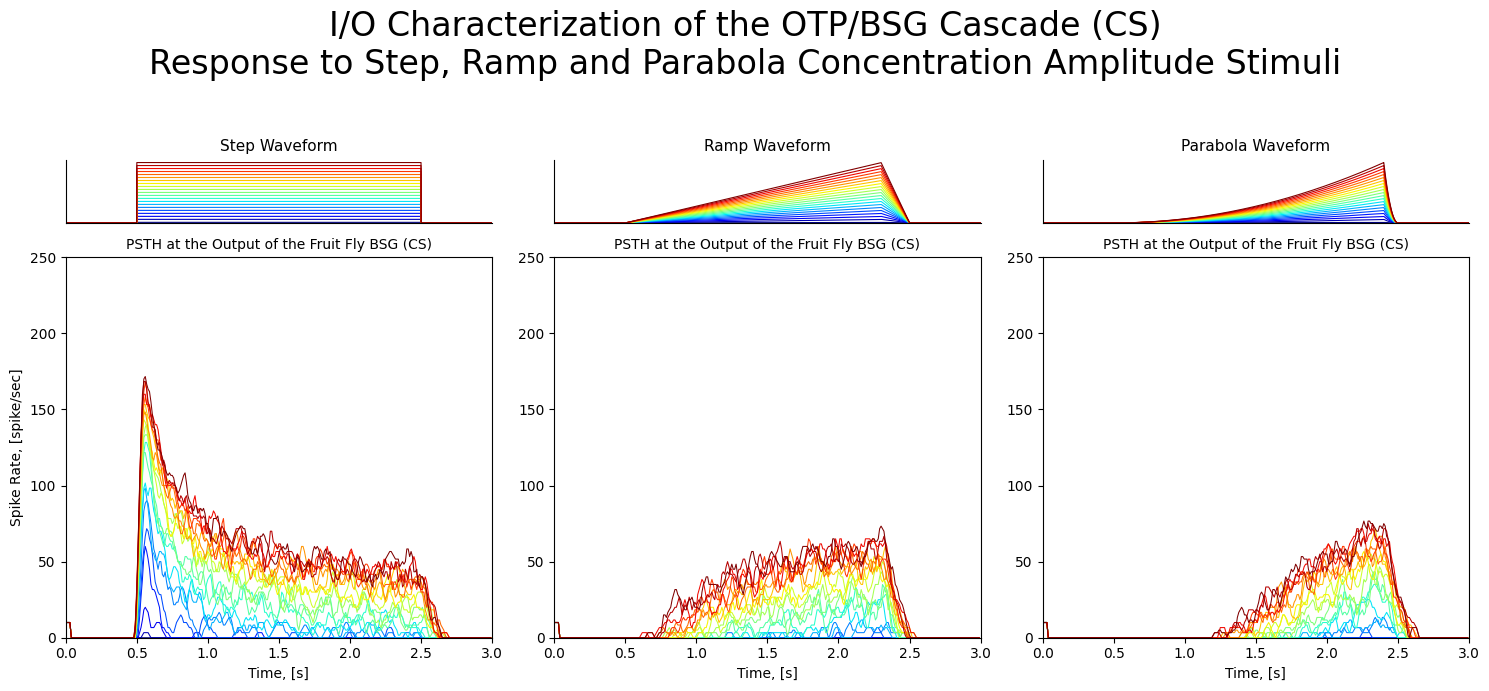

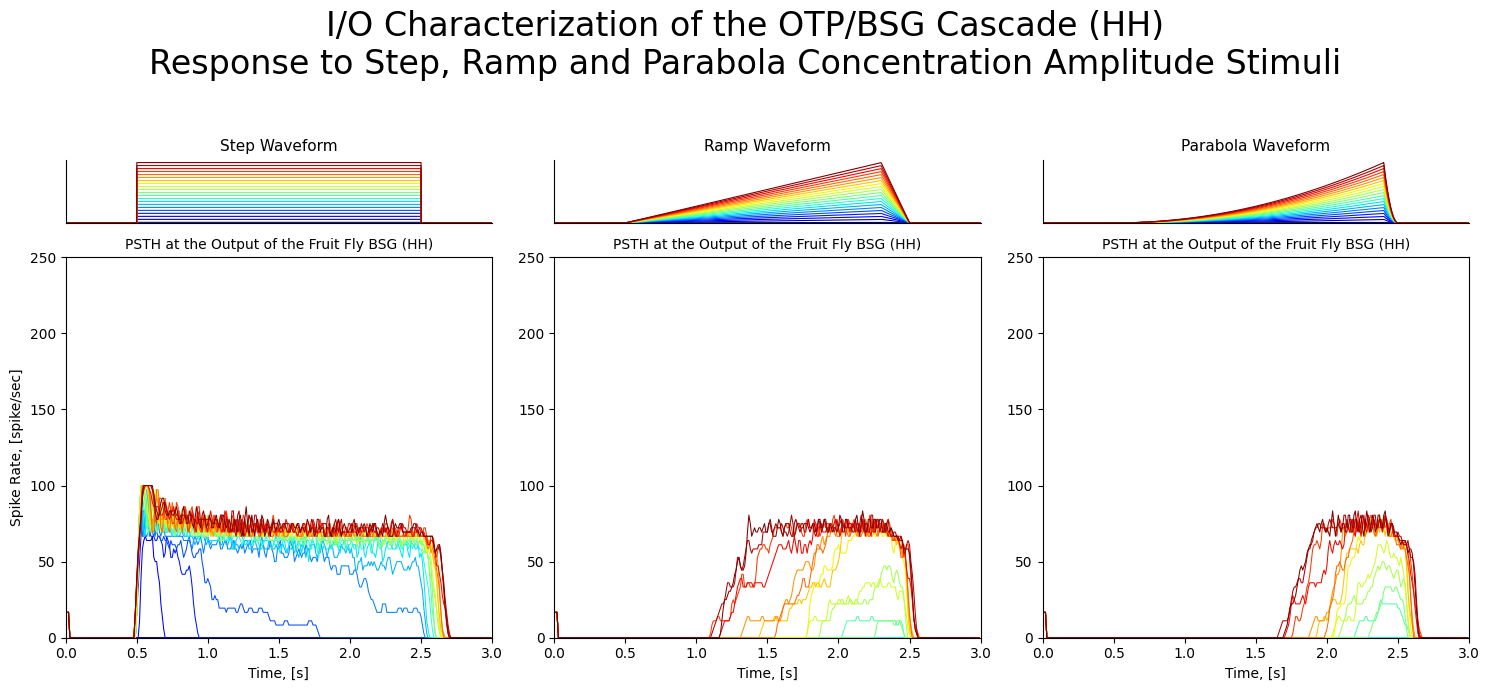

Observation:
Both CS and HH versions of the OTP/BSG cascade preserve the temporal structure of the OTP response.
The CS cascade changes more continuously across amplitudes, while the HH cascade is more thresholded.
This supports the interpretation that the OTP primarily encodes temporal variability and the BSG maps current into spikes.


In [ ]:
# Plot OTP/BSG results

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

cmap = plt.get_cmap("jet")
stimuli = ["step", "ramp", "parabola"]
titles = {
    "step": "Step Waveform",
    "ramp": "Ramp Waveform",
    "parabola": "Parabola Waveform"
}

def smooth_psth(psth, window=5):
    """
    the Smoothing is going to occur only across the PSTH time bins.
    """
    if window <= 1:
        return psth.copy()

    kernel = np.ones(window, dtype=float) / window
    out = np.zeros_like(psth)
    for j in range(psth.shape[1]):
        out[:, j] = np.convolve(psth[:, j], kernel, mode="same")
    return out

def plot_otp_bsg(model_name, results_dict, y_max=250, smooth_window=5):
    fig, axes = plt.subplots(
        2, 3,
        figsize=(15, 7),
        gridspec_kw={"height_ratios": [1, 6]}
    )

    for col, stimulus in enumerate(stimuli):
        data = results_dict[stimulus]
        u = data["u"]
        t_psth = data["t_psth"]
        psth = smooth_psth(data["psth"], window=smooth_window)

        # the top panel is going to be the stimulus
        ax_top = axes[0, col]
        for i in range(N):
            ax_top.plot(t_range, u[:, i], color=cmap(i / (N - 1)), linewidth=0.8)
        ax_top.set_xlim(0, 3.0)
        ax_top.set_ylim(bottom=0)
        ax_top.set_title(titles[stimulus], fontsize=11)
        ax_top.set_xticks([])
        ax_top.set_yticks([])
        ax_top.spines["top"].set_visible(False)
        ax_top.spines["right"].set_visible(False)

        # the bottom panel is going to be the PSTH
        ax = axes[1, col]
        for i in range(N):
            ax.plot(t_psth, psth[:, i], color=cmap(i / (N - 1)), linewidth=0.75)
        ax.set_xlim(0, 3.0)
        ax.set_ylim(0, y_max)
        ax.set_xlabel("Time, [in s]")
        if col == 0:
            ax.set_ylabel("Spike Rate, [in spike/sec]")
        ax.set_title(f"The PSTH at the Output of the Fruit Fly BSG ({model_name})", fontsize=10)

    fig.suptitle(
        f"I/O Characterization of the OTP/BSG Cascade ({model_name})\n"
        f"Response to Step, Ramp and Parabola Concentration Amplitude Stimuli",
        fontsize=24,
        y=0.98
    )
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

# CS is noisier, so we are going to have to smooth a bit more
plot_otp_bsg("CS", otp_bsg_results["CS"], y_max=250, smooth_window=5)

# we know that the HH is cleaner, so we are going to smooth a bit less
plot_otp_bsg("HH", otp_bsg_results["HH"], y_max=250, smooth_window=3)


We noticed that the responses of the OTP/BSG cascade to the step, ramp, and parabola concentration amplitude stimuli essentially show that both the CS and the HH versions of the cascade are able to preserve the temporal structure of the input waveform. In the step stimulus, we can see that both of the models exhibit a strong transient response followed by an adaptation to a lower steady firing rate. As for the ramp stimulus, we can see that the firing rate is going to increase gradually over time as the concentration increases. Moreover, for the parabola stimulus, we are able to observe that the firing rate rises nonlinearly, which could perhaps be reflective of the accelerating concentration profile. These observations seem to ndicate that the temporal variability of the odorant concentration waveform is going to end up being primarily encoded by the OTP stage of the cascade.

Additionally, when comparing the CS and HH neuron models, it is our belief that the CS-based cascade is going to produce smoother and more continuous spike-rate responses across the stimulus amplitudes, which is going to be especially true at lower input levels. In contrast, we find that the HH-based cascade shows stronger threshold behavior and this sort of delayed activation at smaller amplitudes (with sharper transitions once spiking begins). This results in poor onset performance for ramp/parabolic inputs: even at the largest amplitude input, HH takes more than 0.5s to respond (compared to ~0.2s for CS). Despite all of these differences, interestingly, these models produce qualitatively similar output patterns that are going to follow the structure of the input stimulus. This finding is in support of the interpretation that the BSG stage mainly converts the transduction current generated by the OTP stage into spike trains rather than just determining the temporal shape of the response.

**(6) The I/O of the OTP/BSG Cascade in Steady State, The Response of
the OTP/BSG Cascade to Constant Input Stimuli in Steady State,
Lecture #9, slide #19, 2D plot on the right. Simulate and compare
both CS and HH models; comment on your observation.**

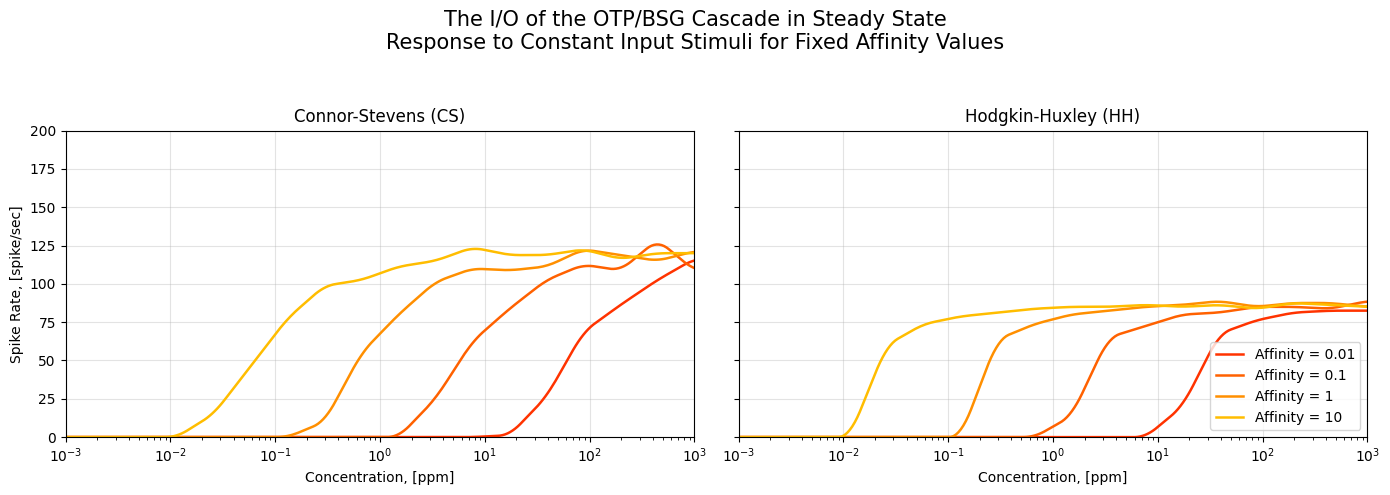

In [ ]:
'''
now we have the final part 6, attempting to replicate
Lecture #9, slide #19 (right 2D plot), comparing CS and HH

the following already defined
OTPModel
simulate_cs_population
simulate_hh_population
'''
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

#again, lets be runtime conscious so that it doesn't run ad naeseum.
dt = 1e-5 #have to
T_ss = 1.0 # total simulation time in seconds
tail_window = 0.20  # and then lets use the last 200 ms for the steady-state rate
t_ss = np.arange(0.0, T_ss, dt)

# this is for the right-panel and lecture-style affinities
affinities = [1e-2, 1e-1, 1.0, 1e1]

# this is going to be the log-spaced concentration amplitudes, which
# is going to match the slide style
concentrations = np.logspace(-3, 3, 18)

# in reading through the slides, we
#find that steady state the lecture emphasizes this concept affinity b/d.
# We fix d and then vary b = affinity * d.
d_fixed = 100.0

#then lets make sure to keep the population modest so the cell stays usable
n_ss_neurons = 4

# our helper functiosn
def make_constant_stimulus(t_range, amp):
    """
        Shape is going to match the OTPModel expectations: [time, R, O, N]
    with R=O=N=1.
    """
    u = np.zeros((len(t_range), 1, 1, 1), dtype=float)
    u[:, 0, 0, 0] = amp
    return u

def steady_state_rate_from_spikes(spikes, dt, tail_window):
    tail_steps = int(round(tail_window / dt))
    tail_spikes = spikes[-tail_steps:]# [tail, Namp, Nneur]
    total_spikes = tail_spikes.sum(axis=(0, 2)) # [Namp]
    n_neurons = tail_spikes.shape[2]
    return total_spikes / (n_neurons * tail_window)

def smooth_log_curve(x, y, n_dense=250, window=11):
    """
    the smoothing is happening for display, by interpolating in log10(x).
    since we don't have as much data points as in the lecture, owing to the
    very high runtime of the cells, to avoid the step like nature of the graph,
    resort to interpolation.
    """
    xlog = np.log10(x)
    xlog_dense = np.linspace(xlog.min(), xlog.max(), n_dense)
    y_dense = np.interp(xlog_dense, xlog, y)

    if window > 1:
        kernel = np.ones(window) / window
        pad = window // 2
        y_pad = np.pad(y_dense, (pad, pad), mode="edge")
        y_dense = np.convolve(y_pad, kernel, mode="valid")

    return 10 ** xlog_dense, y_dense

#now we're going ot run the steady-state OTP -> BSG cascade
cs_ss_rates = np.zeros((len(affinities), len(concentrations)))
hh_ss_rates = np.zeros((len(affinities), len(concentrations)))

model = OTPModel()

for i, aff in enumerate(affinities):
    b_fixed = aff * d_fixed

    for j, conc in enumerate(concentrations):
        u_const = make_constant_stimulus(t_ss, conc)

        #this is the otp output current
        _, _, _, _, _, I = model.sim(t_ss, b_fixed, d_fixed, u_const)
        I_drive = I[:, 0, 0, :] #with the shape [T, 1]

        #CS cascade
        spikes_cs = simulate_cs_population(
            I_drive,
            dt,
            n_neurons=n_ss_neurons,
            sigma=0.85,
            seed=100 + 10*i + j
        )
        cs_ss_rates[i, j] = steady_state_rate_from_spikes(
            spikes_cs, dt, tail_window
        )[0]

        #the HH cascade
        spikes_hh = simulate_hh_population(
            I_drive,
            dt,
            n_neurons=n_ss_neurons,
            input_sigma=0.04,
            seed=200 + 10*i + j
        )
        hh_ss_rates[i, j] = steady_state_rate_from_spikes(
            spikes_hh, dt, tail_window
        )[0]

# plot the lecture style graph with interpolation.
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
cmap = plt.get_cmap("autumn")

for k, aff in enumerate(affinities):
    color = cmap(0.20 + 0.18 * k)

    x_cs, y_cs = smooth_log_curve(concentrations, cs_ss_rates[k], n_dense=250, window=9)
    axes[0].plot(x_cs, y_cs, linewidth=1.8, color=color, label=f"Affinity = {aff:g}")

    x_hh, y_hh = smooth_log_curve(concentrations, hh_ss_rates[k], n_dense=250, window=9)
    axes[1].plot(x_hh, y_hh, linewidth=1.8, color=color, label=f"Affinity = {aff:g}")

for ax, title in zip(
    axes,
    ["Connor-Stevens (CS)", "Hodgkin-Huxley (HH)"]
):
    ax.set_xscale("log")
    ax.set_xlim(concentrations.min(), concentrations.max())
    ax.set_ylim(0, 200)
    ax.set_xlabel("Concentration, [ppm]")
    ax.set_title(title)
    ax.grid(True, alpha=0.35)

axes[0].set_ylabel("Spike Rate, [in spike/sec]")
axes[1].legend(loc="lower right", frameon=True)

fig.suptitle(
    "This is the I/O of the OTP/BSG Cascade in Steady State\n"
    "The Response to Constant Input Stimuli for Some Fixed Affinity Values",
    fontsize=15
)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In steady state, we find that both the Connor–Stevens (CS) and the Hodgkin–Huxley (HH) versions of the OTP/BSG cascade are able to demonstrate the expected sigmoidal relationship between concentration amplitude and spike rate, and then we can see that increasing the ligand–receptor affinity is able to shift the curves to the left so that lower concentrations are then able to produce the same firing rate. This matches the interpretation from Lecture 9 that was mentioned in class, where steady-state behavior depends mainly on the product of the affinity and the concentration amplitude. However, it is apparent that the two neuron models differ slightly in how sharply they turn on, with the CS cascade appearing somewhat more gradual near the onset and the HH cascade entirely more threshold-like, but both show the same overall pattern of thresholding followed by saturation at higher concentrations.


I feel it is important to mention that the plot does not match the lecture figure exactly because, earlier in the notebook, the simulation was adjusted in order to reduce the runtime by using fewer neurons and fewer sampled concentration points, which makes the curves less smooth and slightly shifts their exact values.